# Aurora fio `rand_write` — Engine Statistics

Per-engine run statistics (N, mean, min, median, max) for:\n**Bandwidth** (GiB/s), **IOPS**, **Mean latency** (ms), **CPU** (usr+sys %).\n\nCommon configuration: `bs=1m`, `numjobs=16`, `iodepth=16`, `rw=randwrite`, `runtime=60s`.

## DFS

In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path(".")

In [2]:
def parse_dfs_file(fpath):
    m = re.search(r"fio_dfs_bs(\S+?)_nj(\d+)_iod(\d+)_(\d+)\.json", Path(fpath).name)
    bs, nj, iod, ts = m.group(1), int(m.group(2)), int(m.group(3)), int(m.group(4))

    text = Path(fpath).read_text()
    json_start = text.find("{")
    d    = json.loads(text[json_start:])
    note = "aborted" if text[:json_start].strip() else ""

    job = d["jobs"][0]          # group_reporting=1 → single aggregated job
    w   = job["write"]

    return dict(
        timestamp   = ts,
        block_size  = bs,
        numjobs     = nj,
        iodepth     = iod,
        bw_GiBs     = w["bw_bytes"] / 1024**3,
        iops        = w["iops"],
        lat_mean_ms = w["lat_ns"]["mean"] / 1e6,
        cpu         = job["usr_cpu"] + job["sys_cpu"],
        note        = note,
    )


rows = [parse_dfs_file(p) for p in sorted(RESULTS_DIR.glob("fio_dfs_*.json"))]
df   = pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)
df.index.name = "run"
df.index += 1

print(f"Loaded {len(df)} DFS runs")
df

Loaded 10 DFS runs


,timestamp,block_size,numjobs,iodepth,bw_GiBs,iops,lat_mean_ms,cpu,note
run,,,,,,,,,
1,1781795356,1m,16,16,88.244622,90362.492500,2.706695,88.248364,
2,1781795431,1m,16,16,84.629335,86660.439304,2.819271,93.699441,
3,1781795506,1m,16,16,85.147631,87191.173775,2.823136,76.092669,
4,1781795581,1m,16,16,88.007107,90119.277369,2.701697,96.776593,
5,1781795656,1m,16,16,88.119113,90233.971635,2.701460,90.277601,
6,1781795731,1m,16,16,79.368342,81273.181788,2.992762,99.321050,
7,1781795805,1m,16,16,88.987510,91123.210506,2.678237,90.089925,
8,1781795880,1m,16,16,88.426185,90548.413439,2.688792,96.152764,
9,1781795955,1m,16,16,87.735392,89841.041281,2.704861,98.251791,


### Summary Statistics

In [3]:
METRICS = {
    "bw_GiBs"    : "BW (GiB/s)",
    "iops"       : "IOPS",
    "lat_mean_ms": "Mean Latency (ms)",
    "cpu"    : "CPU (%)",
}

stats = (
    df[list(METRICS)]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .rename(index={"count": "N"})
    .rename(columns=METRICS)
    .T
)
stats["N"] = stats["N"].astype(int)
stats["cv_pct"] = stats["std"] / stats["mean"] * 100
stats = stats[["N", "mean", "std", "cv_pct", "min", "median", "max"]]

pd.set_option("display.float_format", "{:.4f}".format)
stats

,N,mean,std,cv_pct,min,median,max
BW (GiB/s),10,86.7165,2.9642,3.4183,79.3683,88.0631,88.9875
IOPS,10,88797.6537,3035.3419,3.4183,81273.1818,90176.6245,91123.2105
Mean Latency (ms),10,2.7505,0.1002,3.6446,2.6782,2.7033,2.9928
CPU (%),10,92.2300,6.7558,7.3249,76.0927,93.5446,99.3210


## Interception libraries



### libioil / libaio

Files that begin with fio error/signal lines are parsed by skipping to the first `{`;\nabnormally terminated runs are flagged in the `note` column.

In [4]:
def parse_libioil_libaio_file(fpath):
    m = re.search(r"fio_libioil_libaio_bs(\S+?)_nj(\d+)_iod(\d+)_(\d+)\.json", Path(fpath).name)
    bs, nj, iod, ts = m.group(1), int(m.group(2)), int(m.group(3)), int(m.group(4))

    text = Path(fpath).read_text()
    json_start = text.find("{")
    d    = json.loads(text[json_start:])

    job  = d["jobs"][0]
    w    = job["write"]
    note = "aborted" if text[:json_start].strip() else ""

    return dict(
        timestamp   = ts,
        block_size  = bs,
        numjobs     = nj,
        iodepth     = iod,
        bw_GiBs     = w["bw_bytes"] / 1024**3,
        iops        = w["iops"],
        lat_mean_ms = w["lat_ns"]["mean"] / 1e6,
        cpu         = job["usr_cpu"] + job["sys_cpu"],
        note        = note,
    )


rows_il, skipped = [], []
for p in sorted(RESULTS_DIR.glob("fio_libioil_libaio_*.json")):
    try:
        rows_il.append(parse_libioil_libaio_file(p))
    except Exception as e:
        skipped.append((p.name, str(e)))

df_il = pd.DataFrame(rows_il).sort_values("timestamp").reset_index(drop=True)
df_il.index.name = "run"
df_il.index += 1

if skipped:
    print(f"Skipped {len(skipped)} file(s): {[n for n,_ in skipped]}")
print(f"Loaded {len(df_il)} libioil/libaio runs")

Loaded 20 libioil/libaio runs


In [5]:
METRICS = {
    "bw_GiBs"    : "BW (GiB/s)",
    "iops"       : "IOPS",
    "lat_mean_ms": "Mean Latency (ms)",
    "cpu"        : "CPU (%)",
}

stats_il = (
    df_il[list(METRICS)]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .rename(index={"count": "N"})
    .rename(columns=METRICS)
    .T
)
stats_il["N"] = stats_il["N"].astype(int)
stats_il["cv_pct"] = stats_il["std"] / stats_il["mean"] * 100
stats_il = stats_il[["N", "mean", "std", "cv_pct", "min", "median", "max"]]

pd.set_option("display.float_format", "{:.4f}".format)
stats_il

,N,mean,std,cv_pct,min,median,max
BW (GiB/s),20,10.7360,1.3405,12.4863,6.3494,10.7765,14.3121
IOPS,20,10993.7022,1372.7048,12.4863,6501.7666,11035.1322,14655.5506
Mean Latency (ms),20,23.1910,3.1795,13.7102,17.1489,22.8727,35.2316
CPU (%),20,18.3153,2.9812,16.2773,10.6497,19.1746,23.7958


---
### libioil / pvsync2

In [6]:
def parse_simple(fpath, pattern):
    m = re.search(pattern, Path(fpath).name)
    bs, nj, iod, ts = m.group(1), int(m.group(2)), int(m.group(3)), int(m.group(4))
    text = Path(fpath).read_text()
    d    = json.loads(text[text.find("{"):])
    job  = d["jobs"][0]
    w    = job["write"]
    return dict(
        timestamp   = ts,
        block_size  = bs,
        numjobs     = nj,
        iodepth     = iod,
        bw_GiBs     = w["bw_bytes"] / 1024**3,
        iops        = w["iops"],
        lat_mean_ms = w["lat_ns"]["mean"] / 1e6,
        cpu         = job["usr_cpu"] + job["sys_cpu"],
    )

PATTERN = r"fio_\S+?_bs(\S+?)_nj(\d+)_iod(\d+)_(\d+)\.json"

rows_pv2 = [parse_simple(p, PATTERN)
            for p in sorted(RESULTS_DIR.glob("fio_libioil_pvsync2_*.json"))]
df_pv2 = pd.DataFrame(rows_pv2).sort_values("timestamp").reset_index(drop=True)
df_pv2.index.name = "run"
df_pv2.index += 1

print(f"Loaded {len(df_pv2)} libioil/pvsync2 runs")

Loaded 20 libioil/pvsync2 runs


In [7]:
METRICS = {
    "bw_GiBs"    : "BW (GiB/s)",
    "iops"       : "IOPS",
    "lat_mean_ms": "Mean Latency (ms)",
    "cpu"        : "CPU (%)",
}

stats_pv2 = (
    df_pv2[list(METRICS)]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .rename(index={"count": "N"})
    .rename(columns=METRICS)
    .T
)
stats_pv2["N"] = stats_pv2["N"].astype(int)
stats_pv2["cv_pct"] = stats_pv2["std"] / stats_pv2["mean"] * 100
stats_pv2 = stats_pv2[["N", "mean", "std", "cv_pct", "min", "median", "max"]]

pd.set_option("display.float_format", "{:.4f}".format)
stats_pv2

,N,mean,std,cv_pct,min,median,max
BW (GiB/s),20,12.1794,0.1054,0.8653,11.9114,12.1864,12.3691
IOPS,20,12471.6908,107.9140,0.8653,12197.2601,12478.8674,12665.9611
Mean Latency (ms),20,1.1304,0.0084,0.7446,1.1111,1.1321,1.1467
CPU (%),20,12.9211,0.6506,5.0349,11.5381,13.0683,13.7207


---
## dfuse Engines

### dfuse / libaio

In [8]:
rows_dfu_la = [parse_simple(p, PATTERN)
               for p in sorted(RESULTS_DIR.glob("fio_dfuse_libaio_*.json"))]
df_dfu_la = pd.DataFrame(rows_dfu_la).sort_values("timestamp").reset_index(drop=True)
df_dfu_la.index.name = "run"
df_dfu_la.index += 1

print(f"Loaded {len(df_dfu_la)} dfuse/libaio runs")
df_dfu_la

Loaded 12 dfuse/libaio runs


,timestamp,block_size,numjobs,iodepth,bw_GiBs,iops,lat_mean_ms,cpu
run,,,,,,,,
1,1781801277,1m,16,16,29.2157,29916.9014,8.3808,99.0360
2,1781801353,1m,16,16,29.0287,29725.3712,8.4337,98.7348
3,1781801429,1m,16,16,28.9548,29649.7558,8.4561,99.2262
4,1781801505,1m,16,16,29.4340,30140.4643,8.3258,98.8649
5,1781801581,1m,16,16,29.0307,29727.4212,8.4374,99.6321
6,1781801658,1m,16,16,29.0847,29782.7703,8.4221,99.2351
7,1781801734,1m,16,16,28.9326,29626.9895,8.4623,98.6552
8,1781801810,1m,16,16,28.8706,29563.4573,8.4810,98.6756
9,1781801886,1m,16,16,29.0090,29705.2549,8.4439,98.7064


In [9]:
stats_dfu_la = (
    df_dfu_la[list(METRICS)]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .rename(index={"count": "N"})
    .rename(columns=METRICS)
    .T
)
stats_dfu_la["N"] = stats_dfu_la["N"].astype(int)
stats_dfu_la["cv_pct"] = stats_dfu_la["std"] / stats_dfu_la["mean"] * 100
stats_dfu_la = stats_dfu_la[["N", "mean", "std", "cv_pct", "min", "median", "max"]]

pd.set_option("display.float_format", "{:.4f}".format)
stats_dfu_la

,N,mean,std,cv_pct,min,median,max
BW (GiB/s),12,28.8807,0.5434,1.8814,27.2332,28.9819,29.4340
IOPS,12,29573.8752,556.4113,1.8814,27886.8019,29677.5054,30140.4643
Mean Latency (ms),12,8.4813,0.1637,1.9301,8.3258,8.4500,8.9813
CPU (%),12,99.0460,0.3273,0.3305,98.6552,99.0603,99.6321


---
### dfuse / pvsync2

In [10]:
rows_dfu_pv2 = [parse_simple(p, PATTERN)
                for p in sorted(RESULTS_DIR.glob("fio_dfuse_pvsync2_*.json"))]
df_dfu_pv2 = pd.DataFrame(rows_dfu_pv2).sort_values("timestamp").reset_index(drop=True)
df_dfu_pv2.index.name = "run"
df_dfu_pv2.index += 1

print(f"Loaded {len(df_dfu_pv2)} dfuse/pvsync2 runs")

Loaded 12 dfuse/pvsync2 runs


In [11]:
stats_dfu_pv2 = (
    df_dfu_pv2[list(METRICS)]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .rename(index={"count": "N"})
    .rename(columns=METRICS)
    .T
)
stats_dfu_pv2["N"] = stats_dfu_pv2["N"].astype(int)
stats_dfu_pv2["cv_pct"] = stats_dfu_pv2["std"] / stats_dfu_pv2["mean"] * 100
stats_dfu_pv2 = stats_dfu_pv2[["N", "mean", "std", "cv_pct", "min", "median", "max"]]

pd.set_option("display.float_format", "{:.4f}".format)
stats_dfu_pv2

,N,mean,std,cv_pct,min,median,max
BW (GiB/s),12,38.9961,0.8220,2.1080,37.2190,39.2919,39.5250
IOPS,12,39931.9768,841.7486,2.1080,38112.2315,40234.9128,40473.5921
Mean Latency (ms),12,0.3620,0.0088,2.4253,0.3567,0.3587,0.3811
CPU (%),12,99.1670,0.1986,0.2003,98.9334,99.1268,99.4991


---
## BW Summary — All Engines

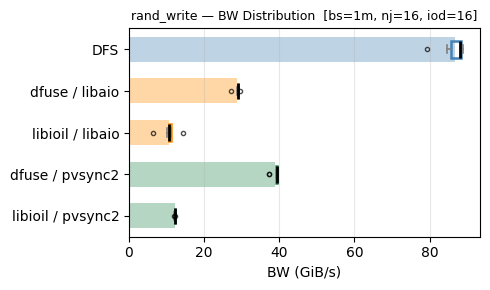

,N,Mean (GiB/s),Median (GiB/s),Stdev (GiB/s),CV (%),Min (GiB/s),Max (GiB/s)
Engine,,,,,,,
DFS,10,86.716,88.063,2.964,3.418,79.368,88.988
dfuse / libaio,12,28.881,28.982,0.543,1.881,27.233,29.434
libioil / libaio,20,10.736,10.776,1.341,12.486,6.349,14.312
dfuse / pvsync2,12,38.996,39.292,0.822,2.108,37.219,39.525
libioil / pvsync2,20,12.179,12.186,0.105,0.865,11.911,12.369


In [47]:
engines = {
    "DFS":               df,
    "dfuse / libaio":    df_dfu_la,
    "libioil / libaio":  df_il,
    "dfuse / pvsync2":   df_dfu_pv2,
    "libioil / pvsync2": df_pv2,
}

STYLE = {
    "DFS":               dict(color="steelblue",  hatch="",    alpha=0.85),
    "dfuse / libaio":    dict(color="darkorange", hatch="",    alpha=0.85),
    "libioil / libaio":  dict(color="darkorange", hatch="///", alpha=0.6),
    "dfuse / pvsync2":   dict(color="seagreen",   hatch="",    alpha=0.85),
    "libioil / pvsync2": dict(color="seagreen",   hatch="///", alpha=0.6),
}

bw_summary = pd.DataFrame([
    {
        "Engine":         name,
        "N":              len(d),
        "Mean (GiB/s)":   d["bw_GiBs"].mean(),
        "Median (GiB/s)": d["bw_GiBs"].median(),
        "Stdev (GiB/s)":  d["bw_GiBs"].std(),
        "CV (%)":         d["bw_GiBs"].std() / d["bw_GiBs"].mean() * 100,
        "Min (GiB/s)":    d["bw_GiBs"].min(),
        "Max (GiB/s)":    d["bw_GiBs"].max(),
    }
    for name, d in engines.items()
]).set_index("Engine")
bw_summary["N"] = bw_summary["N"].astype(int)
pd.set_option("display.float_format", "{:.3f}".format)

names = list(engines.keys())
fig, ax = plt.subplots(figsize=(5, 3))

# background bars (mean, semi-transparent)
for i, name in enumerate(names):
    s = STYLE[name]
    ax.barh(i, engines[name]["bw_GiBs"].mean(), height=0.6,
            color=s["color"], hatch=s["hatch"], alpha=0.35, edgecolor="none")

# overlay box plots
bp = ax.boxplot(
    [engines[n]["bw_GiBs"].values for n in names],
    vert=False, patch_artist=True,
    positions=range(len(names)), widths=0.4,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="gray", linewidth=1.2),
    capprops=dict(color="gray", linewidth=1.2),
    flierprops=dict(marker="o", markersize=3, color="gray", alpha=0.7),
)
for patch, name in zip(bp["boxes"], names):
    patch.set_facecolor("none")
    patch.set_edgecolor(STYLE[name]["color"])
    patch.set_linewidth(1.8)

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel("BW (GiB/s)")
ax.set_title("rand_write — BW Distribution  [bs=1m, nj=16, iod=16]", fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

bw_summary

---
## CPU Usage Summary — All Engines

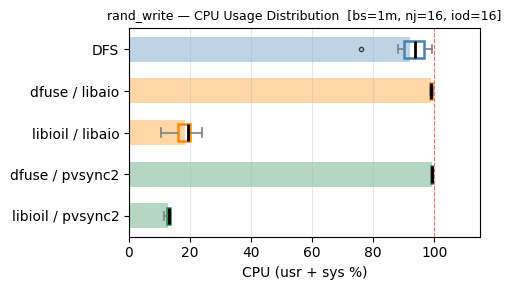

,N,Mean (%),Median (%),Stdev (%),Min (%),Max (%)
Engine,,,,,,
DFS,10,92.23,93.54,6.76,76.09,99.32
dfuse / libaio,12,99.05,99.06,0.33,98.66,99.63
libioil / libaio,20,18.32,19.17,2.98,10.65,23.80
dfuse / pvsync2,12,99.17,99.13,0.20,98.93,99.50
libioil / pvsync2,20,12.92,13.07,0.65,11.54,13.72


In [46]:
cpu_summary = pd.DataFrame([
    {
        "Engine":     name,
        "N":          len(d),
        "Mean (%)":   d["cpu"].mean(),
        "Median (%)": d["cpu"].median(),
        "Stdev (%)":  d["cpu"].std(),
        "Min (%)":    d["cpu"].min(),
        "Max (%)":    d["cpu"].max(),
    }
    for name, d in engines.items()
]).set_index("Engine")
cpu_summary["N"] = cpu_summary["N"].astype(int)
pd.set_option("display.float_format", "{:.2f}".format)

fig, ax = plt.subplots(figsize=(5, 3))

# background bars (mean, semi-transparent)
for i, name in enumerate(names):
    s = STYLE[name]
    ax.barh(i, engines[name]["cpu"].mean(), height=0.6,
            color=s["color"], hatch=s["hatch"], alpha=0.35, edgecolor="none")

# overlay box plots
bp = ax.boxplot(
    [engines[n]["cpu"].values for n in names],
    vert=False, patch_artist=True,
    positions=range(len(names)), widths=0.4,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="gray", linewidth=1.2),
    capprops=dict(color="gray", linewidth=1.2),
    flierprops=dict(marker="o", markersize=3, color="gray", alpha=0.7),
)
for patch, name in zip(bp["boxes"], names):
    patch.set_facecolor("none")
    patch.set_edgecolor(STYLE[name]["color"])
    patch.set_linewidth(1.8)

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel("CPU (usr + sys %)")
ax.set_xlim(0, 115)
ax.axvline(100, color="red", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_title("rand_write — CPU Usage Distribution  [bs=1m, nj=16, iod=16]", fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

cpu_summary